In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

import os
import matplotlib.pyplot as plt
import datetime as dt

from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.losses import MeanAbsoluteError
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.preprocessing import StandardScaler

2024-05-18 23:13:08.314550: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-05-18 23:13:08.409845: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-18 23:13:08.409916: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-18 23:13:08.412017: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-05-18 23:13:08.430777: I tensorflow/core/platform/cpu_feature_guar

In [2]:
df = pd.read_csv('./Starbucks_stock_history.csv')
df.drop(columns=['Dividends', 'Stock Splits', 'Volume'], inplace=True)
df.head()


,Date,Open,High,Low,Close
0,1992-06-26,0.270957,0.287086,0.264507,0.277409
1,1992-06-29,0.280635,0.303215,0.274183,0.296763
2,1992-06-30,0.303215,0.306440,0.283860,0.287086
3,1992-07-01,0.290312,0.296763,0.280635,0.293538
4,1992-07-02,0.296763,0.296763,0.287086,0.293538


In [3]:
n=len(df)
step = 5 # Average Working Days a week
train_start = 21 * 12 * 22
train_end = train_start + (21 * 12 * 2) # 5 years
val_end = train_end + 21 * 12 * 2

learning_rate = 0.001
epochs = 1000

In [4]:
print(df['Date'][train_start])
print(df['Date'][train_end])
print(df['Date'][val_end])
print(df['Date'][n-1])

2014-07-01
2016-06-30
2018-07-02
2021-10-01


In [5]:
def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
    data = []
    labels = []

    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset) - target_size

    for i in range(start_index, end_index):
        indices = range(i-history_size, i, step)
        data.append(dataset[indices])

        if single_step:
            labels.append(target[i+target_size])
        else:
            labels.append(target[i:i+target_size])

    return np.array(data), np.array(labels)

In [6]:
multi_data = df.drop(columns=['Date'], axis=1).values

In [7]:
TRAIN_SPLIT = train_end
VAL_SPLIT = val_end
past_history = 21 * 12 * 1 # 1 years back
future_target = 21 * 12 # 1 year ahead

STEP = step

x_train_single, y_train_single = multivariate_data(multi_data, multi_data[:, 1], 0, TRAIN_SPLIT,
                                                   past_history,
                                                   future_target, STEP,
                                                   single_step=True)
x_val_single, y_val_single = multivariate_data(multi_data, multi_data[:, 1],
                                               TRAIN_SPLIT, VAL_SPLIT, past_history,
                                               future_target, STEP,
                                               single_step=True)
x_test_single, y_test_single = multivariate_data(multi_data, multi_data[:, 1],
                                               VAL_SPLIT, None, past_history,
                                               future_target, STEP,
                                               single_step=True)

In [8]:
print(x_train_single.shape)
print ('Single window of past history : {}'.format(x_train_single[0].shape))
print(x_train_single.shape[-2:])

(5796, 51, 4)
Single window of past history : (51, 4)
(51, 4)


In [9]:
scaler = StandardScaler()

x_train_single_scaled = scaler.fit_transform(x_train_single.reshape(-1, x_train_single.shape[-1])).reshape(x_train_single.shape)
x_test_single_scaled = scaler.transform(x_test_single.reshape(-1, x_test_single.shape[-1])).reshape(x_test_single.shape)
x_val_single_scaled = scaler.transform(x_val_single.reshape(-1, x_val_single.shape[-1])).reshape(x_val_single.shape)

In [10]:
y_scaler = StandardScaler()
y_train_single_scaled = y_scaler.fit_transform(y_train_single.reshape(-1, 1)).reshape(y_train_single.shape)
y_test_single_scaled = y_scaler.transform(y_test_single.reshape(-1, 1)).reshape(y_test_single.shape)
y_val_single_scaled = y_scaler.transform(y_val_single.reshape(-1, 1)).reshape(y_val_single.shape)

In [11]:
BUFFER_SIZE = 10000
BATCH_SIZE = 16
EVALUATION_INTERVAL = 200

train_data_single = tf.data.Dataset.from_tensor_slices((x_train_single_scaled, y_train_single_scaled))
train_data_single = train_data_single.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_data_single = tf.data.Dataset.from_tensor_slices((x_val_single_scaled, y_val_single_scaled))
val_data_single = val_data_single.batch(BATCH_SIZE).repeat()

test_data_single = tf.data.Dataset.from_tensor_slices((x_test_single_scaled, y_test_single_scaled))
test_data_single = test_data_single.batch(BATCH_SIZE).repeat()

2024-05-18 23:13:16.020838: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-05-18 23:13:16.072436: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-05-18 23:13:16.072558: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-05-18 23:13:16.075620: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-05-18 23:13:16.075730: I external/local_xla/xla/stream_executor

In [12]:
def create_model(time_steps, num_features):
    i = Input(shape=(time_steps, num_features))
    x = LSTM(units=20, return_sequences=True)(i)
    x = Dropout(0.2)(x)
    x = LSTM(units=20)(x)
    x = Dropout(0.2)(x)
    x = BatchNormalization()(x)
    x = Dense(1)(x)
    model = Model(inputs=i, outputs=x)
    return model

In [13]:
Model1 = create_model(x_train_single.shape[1], x_train_single.shape[2])

In [14]:
Model1.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 51, 4)]           0         
                                                                 
 lstm (LSTM)                 (None, 51, 20)            2000      
                                                                 
 dropout (Dropout)           (None, 51, 20)            0         
                                                                 
 lstm_1 (LSTM)               (None, 20)                3280      
                                                                 
 dropout_1 (Dropout)         (None, 20)                0         
                                                                 
 batch_normalization (Batch  (None, 20)                80        
 Normalization)                                                  
                                                             

In [15]:
Model1.compile(optimizer=RMSprop(learning_rate=learning_rate), loss=MeanAbsoluteError(), metrics=['mae'])

In [16]:
checkpointer = ModelCheckpoint(filepath = 'weights_best.hdf5', verbose = 1, save_best_only = True)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
his=Model1.fit(train_data_single, 
               steps_per_epoch=EVALUATION_INTERVAL, 
               epochs=100, 
               validation_data=val_data_single, 
               batch_size=BATCH_SIZE, 
               callbacks=[checkpointer, early_stopping],
               validation_steps=50)

Epoch 1/100


2024-05-18 23:13:25.429442: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-05-18 23:13:27.679810: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f53840e0d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-05-18 23:13:27.679932: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2024-05-18 23:13:27.692824: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1716048807.829806   19993 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


199/200 [============================>.] - ETA: 0s - loss: 0.4488 - mae: 0.4488
Epoch 1: val_loss improved from inf to 2.40864, saving model to weights_best.hdf5
200/200 [==============================] - 17s 42ms/step - loss: 0.4481 - mae: 0.4481 - val_loss: 2.4086 - val_mae: 2.4086
Epoch 2/100
  3/200 [..............................] - ETA: 5s - loss: 0.4168 - mae: 0.4168

/home/wbchn/miniconda3/envs/TensorFlow-DLN/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


200/200 [==============================] - ETA: 0s - loss: 0.3601 - mae: 0.3601
Epoch 2: val_loss improved from 2.40864 to 1.15007, saving model to weights_best.hdf5
200/200 [==============================] - 9s 43ms/step - loss: 0.3601 - mae: 0.3601 - val_loss: 1.1501 - val_mae: 1.1501
Epoch 3/100
199/200 [============================>.] - ETA: 0s - loss: 0.3134 - mae: 0.3134
Epoch 3: val_loss improved from 1.15007 to 0.77087, saving model to weights_best.hdf5
200/200 [==============================] - 8s 38ms/step - loss: 0.3142 - mae: 0.3142 - val_loss: 0.7709 - val_mae: 0.7709
Epoch 4/100
200/200 [==============================] - ETA: 0s - loss: 0.3183 - mae: 0.3183
Epoch 4: val_loss did not improve from 0.77087
200/200 [==============================] - 8s 39ms/step - loss: 0.3183 - mae: 0.3183 - val_loss: 1.0168 - val_mae: 1.0168
Epoch 5/100
200/200 [==============================] - ETA: 0s - loss: 0.2942 - mae: 0.2942
Epoch 5: val_loss improved from 0.77087 to 0.57360, saving 

In [17]:
Model1.load_weights('weights_best.hdf5')

In [18]:
pred = y_scaler.inverse_transform(Model1.predict(x_test_single_scaled))

10/10 [==============================] - 2s 16ms/step


In [19]:
def create_time_steps(length):
    return list(range(-length, 0))

def show_plot(plot_data, delta, title):
    labels = ['History', 'True Future', 'Model Prediction']
    marker = ['.-', 'rx', 'go']
    time_steps = create_time_steps(plot_data[0].shape[0])
    if delta:
        future = delta
    else:
        future = 0

    plt.title(title)
    for i, x in enumerate(plot_data):
        if i:
            plt.plot(future, plot_data[i], marker[i], markersize=10,
                   label=labels[i])
        else:
            plt.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])
        plt.legend()
        plt.xlim([time_steps[0], (future+5)*2])
        plt.xlabel('Time-Step')
    
    return plt

1/1 [==============================] - 1s 1s/step


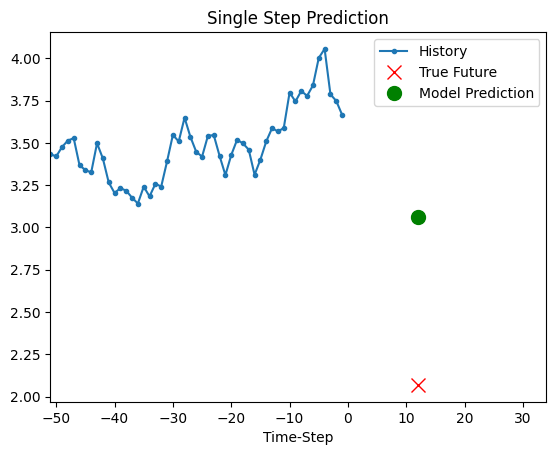

1/1 [==============================] - 0s 45ms/step


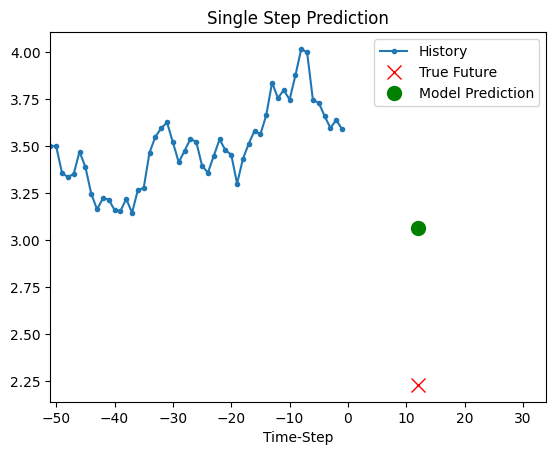

1/1 [==============================] - 0s 46ms/step


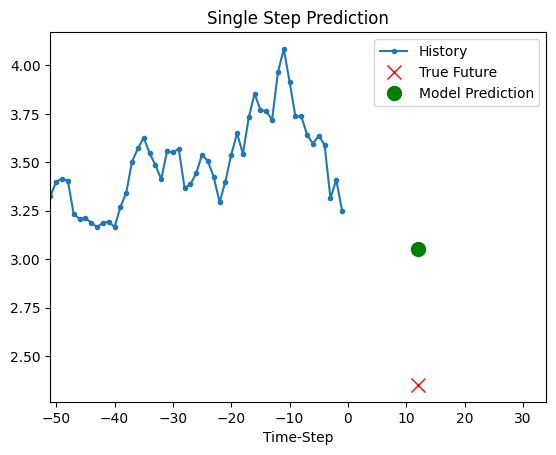

1/1 [==============================] - 0s 57ms/step


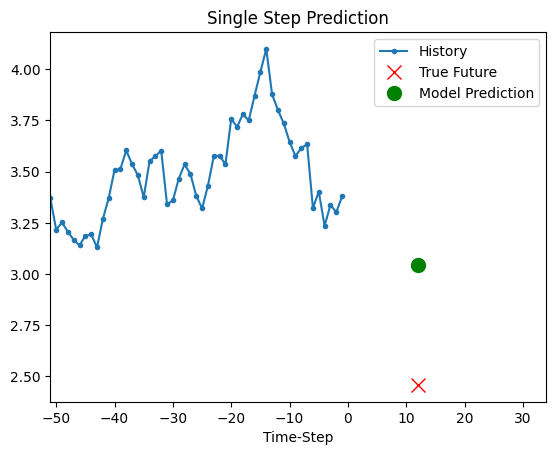

1/1 [==============================] - 0s 51ms/step


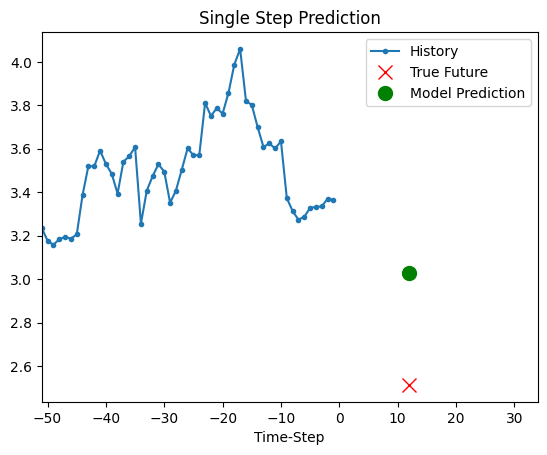

In [20]:
for x, y in val_data_single.take(5):
    plot = show_plot([x[0][:, 1].numpy(), y[0].numpy(),
                    Model1.predict(x)[0]], 12,
                   'Single Step Prediction')
    plot.show()